# 1. EDA

## Aircraft Engine Predictive Maintenance - RUL Prediction
Dataset: NASA C-MAPSS FD001

### Import libraries and load dataset

In [129]:
# Import Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

In [131]:
# import raw dataset
df = pd.read_csv(
    r'..\data\raw\train_FD001.txt',
    sep=r'\s+', 
    header=None,
    names=columns,
    engine='python'
)

In [132]:
df = df.dropna(axis=1)

In [133]:
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


The FD001 dataset contains run to failure records of turbofan engines.
Each row represents one operatinal cycle of an engine with sensor readings.

### Basic overview of dataset

In [134]:
df.shape

(20631, 26)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [136]:
df.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [137]:
df.duplicated().sum()

0

In [138]:
df['engine_id'].nunique()

100

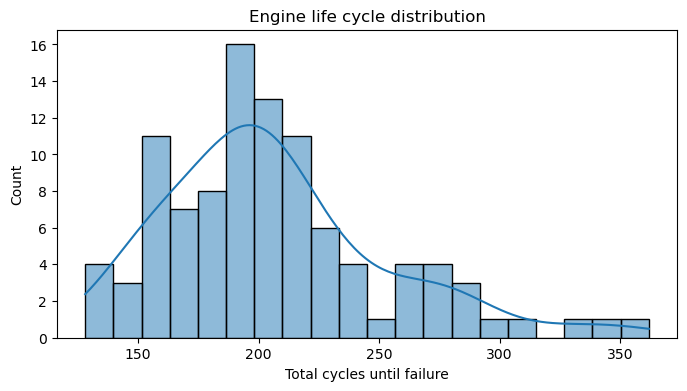

In [139]:
# Engine Life Distribution

engine_life = df.groupby('engine_id')['cycle'].max()
plt.figure(figsize=(8,4))
sns.histplot(engine_life, bins=20, kde=True)
plt.title('Engine life cycle distribution')
plt.xlabel('Total cycles until failure')
plt.ylabel('Count')
plt.show()

In [140]:
# Operating condition check 

for i in range(1,4):
    print(df[[f'op_setting_{i}']].describe())

       op_setting_1
count  20631.000000
mean      -0.000009
std        0.002187
min       -0.008700
25%       -0.001500
50%        0.000000
75%        0.001500
max        0.008700
       op_setting_2
count  20631.000000
mean       0.000002
std        0.000293
min       -0.000600
25%       -0.000200
50%        0.000000
75%        0.000300
max        0.000600
       op_setting_3
count       20631.0
mean          100.0
std             0.0
min           100.0
25%           100.0
50%           100.0
75%           100.0
max           100.0


All Operating settings remain constant across cycles. This confirms that FD001 represents a single opreating condition,
so operating settings can be safely removed during preprocessing.

In [141]:
# Sensor Variance Analysis

sensor_cols = [f'sensor_{i}' for i in range(1,20)]
sensor_variance = df[sensor_cols].var().sort_values()

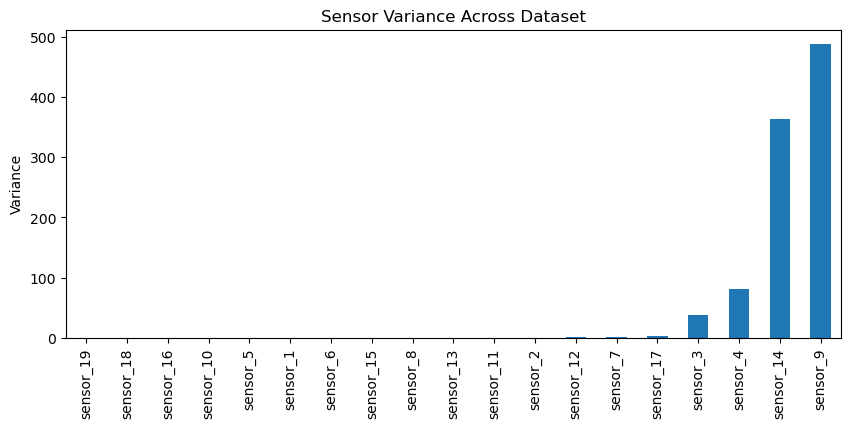

In [142]:
plt.figure(figsize=(10,4))
sensor_variance.plot(kind='bar')
plt.title('Sensor Variance Across Dataset')
plt.ylabel("Variance")
plt.show()

Sensors with near zero variance fo not contribute useful information for degredation modeling and can be removed.

In [143]:
low_variance_sensors = sensor_variance[sensor_variance < 0.01].index.tolist()
low_variance_sensors

['sensor_19',
 'sensor_18',
 'sensor_16',
 'sensor_10',
 'sensor_5',
 'sensor_1',
 'sensor_6',
 'sensor_15',
 'sensor_8',
 'sensor_13']

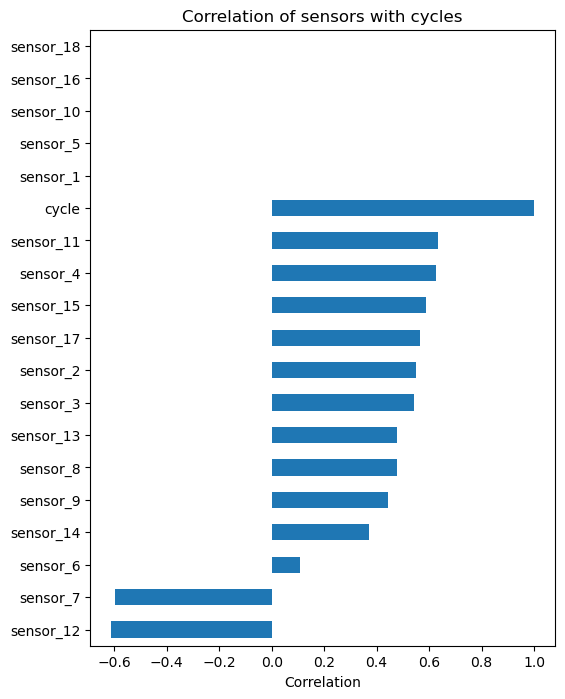

In [144]:
# Correlation with Engine cycle

corr_with_cycle = df[sensor_cols + ['cycle']].corr()['cycle'].sort_values()
plt.figure(figsize=(6,8))
corr_with_cycle[:-1].plot(kind='barh')
plt.title('Correlation of sensors with cycles')
plt.xlabel('Correlation')
plt.show()

Sensors with higher absolute correlation to cycle number are strong candidates for degradation modeling.

### Engine-wise Time-Series Check

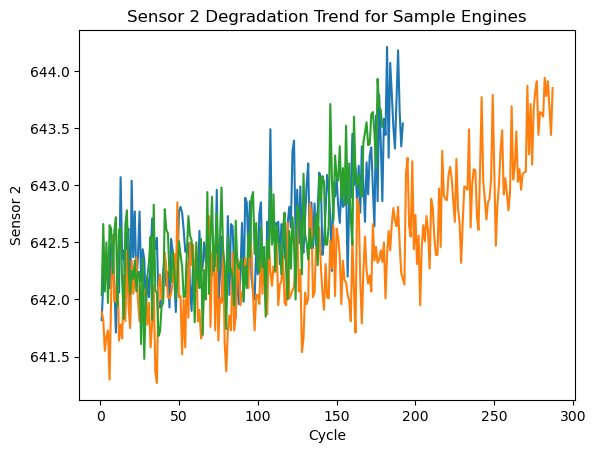

In [149]:
# picking few engines to visualize time-series behavior
sample_engines = df['engine_id'].unique()[:3]

plt.figure()
for eng in sample_engines:
    engine_data = df[df['engine_id'] == eng]
    plt.plot(engine_data['cycle'], engine_data['sensor_2'])

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Degradation Trend for Sample Engines")
plt.show()

In [147]:
sample_engines

array([1, 2, 3], dtype=int64)

### Noise & Non-Linearity in Sensor Signals

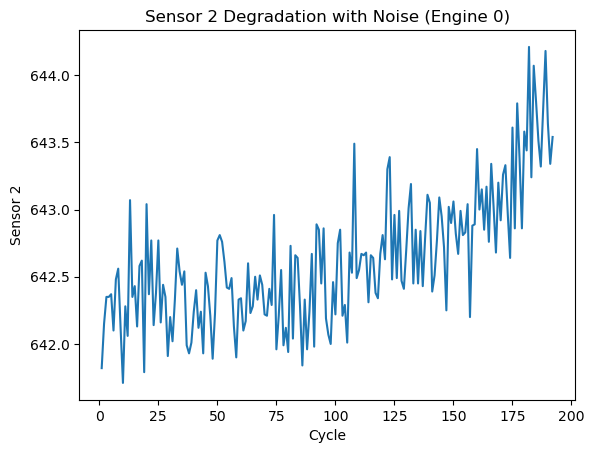

In [148]:
engine_0 = df[df['engine_id'] == 1]

plt.figure()
plt.plot(engine_0['cycle'], engine_0['sensor_2'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Degradation with Noise (Engine 0)")
plt.show()

## EDA Summary
- FD001 contains 100 engines operating under a single condition.
- Engine lifetimes vary significantly, motivating RUL prediction.
- Operating settings are constant and can be removed.
- Sensors with higher absolute correlation to cycle number are strong candidates for degradation modeling.
- Each engine represents an independent noisy time-series, requiring engine-wise splitting and favoring non-linear models for accurate RUL prediction.

These findings guide feature selection and model design in upcoming phases.